In [1]:
import os
import random
import pickle
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

CSV_PATH = "data/dataset_processed.csv" 
TFIDF_MAX_FEATURES = 10000
SVD_COMPONENTS = 300
TRAIN_VAL_SPLIT = 0.2
BATCH_SIZE = 256
EPOCHS_SUPERVISED = 8
EMBEDDING_DIM = 64
TRIPLET_SAMPLE_SIZE = 50000

In [2]:
df = pd.read_csv(CSV_PATH)

In [3]:
numeric_cols = [
    "valence","acousticness","danceability","energy","instrumentalness",
    "liveness","loudness","speechiness","tempo","duration_min","popularity"
]

categorical_cols = ["artists", "language", "decade", "mode", "key", "explicit"]
text_col = "tokens"

df[numeric_cols] = df[numeric_cols].fillna(0.0)
df[text_col] = df[text_col].fillna("")
df[categorical_cols] = df[categorical_cols].fillna("NA")


In [4]:
def clean_artist_field(x):
    s = str(x)
    if s.startswith("[") and s.endswith("]"):
        s2 = s.strip()[1:-1].strip()
        s2 = s2.replace("'", "").replace('"', '')
        first = s2.split(",")[0].strip()
        return first
    return s

sample0 = str(df["artists"].iloc[0])
if sample0.startswith("[") and sample0.endswith("]"):
    print("Limpiando campo 'artists' de formato lista-string...")
    df["artists"] = df["artists"].apply(clean_artist_field)
else:
    print("'artists' no parece lista-string, no se modifica.")

# LabelEncode
label_encoders = {}
X_cat = {}
cat_cardinalities = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    le.fit(df[col].values)
    label_encoders[col] = le
    X_cat[col] = le.transform(df[col].values)
    cat_cardinalities[col] = len(le.classes_)
    print(f"Col: {col}  -> categorías: {cat_cardinalities[col]}")

cat_cols_ordered = categorical_cols


Limpiando campo 'artists' de formato lista-string...
Col: artists  -> categorías: 6992
Col: language  -> categorías: 2
Col: decade  -> categorías: 7
Col: mode  -> categorías: 2
Col: key  -> categorías: 12
Col: explicit  -> categorías: 2


In [5]:
scaler = MinMaxScaler()
X_num = scaler.fit_transform(df[numeric_cols].values)
print("X_num shape:", X_num.shape)

X_num shape: (27281, 11)


In [6]:
print("Construyendo TF-IDF (max_features=%d)..." % TFIDF_MAX_FEATURES)
tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1,2), min_df=2)
X_text_tfidf = tfidf.fit_transform(df[text_col].astype(str).values)
print("TF-IDF shape:", X_text_tfidf.shape)

n_components = min(SVD_COMPONENTS, X_text_tfidf.shape[1]-1)
print("Reduciendo TF-IDF a %d componentes con TruncatedSVD..." % n_components)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_SEED)
X_text = svd.fit_transform(X_text_tfidf)
print("X_text shape (SVD):", X_text.shape)

Construyendo TF-IDF (max_features=10000)...
TF-IDF shape: (27281, 10000)
Reduciendo TF-IDF a 300 componentes con TruncatedSVD...
X_text shape (SVD): (27281, 300)


In [7]:
for col in cat_cols_ordered:
    arr = X_cat[col]
    print(col, "-> shape:", arr.shape, " sample:", arr[:3])

sample_idx = 0
print("\nEjemplo (fila 0) tamaños:")
print(" X_num:", X_num[sample_idx].shape)
print(" X_text:", X_text[sample_idx].shape)
for col in cat_cols_ordered:
    print(f" {col} (int):", X_cat[col][sample_idx])


artists -> shape: (27281,)  sample: [1947 1947 1873]
language -> shape: (27281,)  sample: [0 0 0]
decade -> shape: (27281,)  sample: [0 0 0]
mode -> shape: (27281,)  sample: [1 0 1]
key -> shape: (27281,)  sample: [7 4 1]
explicit -> shape: (27281,)  sample: [0 0 0]

Ejemplo (fila 0) tamaños:
 X_num: (11,)
 X_text: (300,)
 artists (int): 1947
 language (int): 0
 decade (int): 0
 mode (int): 1
 key (int): 7
 explicit (int): 0


In [8]:
y = df["was_trending"].fillna(0).astype(int).values

stratify_param = y if len(np.unique(y)) > 1 and np.min(np.bincount(y)) > 5 else None

indices = np.arange(len(df))
idx_train, idx_val = train_test_split(indices, test_size=TRAIN_VAL_SPLIT, random_state=RANDOM_SEED, stratify=stratify_param)

print("Tamaños: train =", len(idx_train), " val =", len(idx_val))
print("Positivos train/val:", y[idx_train].sum(), y[idx_val].sum())

def build_input_dict(idx_array):
    inputs = {
        "numeric_input": X_num[idx_array],
        "text_input": X_text[idx_array]
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col][idx_array]
    return inputs

train_inputs = build_input_dict(idx_train)
val_inputs = build_input_dict(idx_val)
y_train = y[idx_train]
y_val = y[idx_val]

print("Train inputs prepared. Ejemplo shapes:")
for k,v in train_inputs.items():
    print(" ", k, "->", getattr(v, "shape", None))
print("y_train shape:", y_train.shape)

Tamaños: train = 21824  val = 5457
Positivos train/val: 4505 1127
Train inputs prepared. Ejemplo shapes:
  numeric_input -> (21824, 11)
  text_input -> (21824, 300)
  artists_input -> (21824,)
  language_input -> (21824,)
  decade_input -> (21824,)
  mode_input -> (21824,)
  key_input -> (21824,)
  explicit_input -> (21824,)
y_train shape: (21824,)


In [9]:
assert X_num.shape[0] == len(df)
assert X_text.shape[0] == len(df)
for col in cat_cols_ordered:
    assert X_cat[col].shape[0] == len(df)

**Arquitectura Multimodelo**

In [10]:
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

ARTIST_WEIGHT = 16.0
EMBEDDING_DIM = 64

numeric_in = layers.Input(shape=(X_num.shape[1],), name="numeric_input")
text_in    = layers.Input(shape=(X_text.shape[1],), name="text_input")

cat_inputs = {}
cat_embs = []
artist_emb_index = None

for i, col in enumerate(cat_cols_ordered):
    inp = layers.Input(shape=(1,), dtype="int32", name=f"{col}_input")
    cat_inputs[col] = inp

    vocab = int(cat_cardinalities[col]) + 1
    emb_dim = min(50, max(4, int(1 + np.log2(max(2, cat_cardinalities[col])) * 4)))

    emb = layers.Embedding(input_dim=vocab, 
                           output_dim=emb_dim, 
                           name=f"{col}_emb")(inp)
    
    emb = layers.Flatten()(emb)

    cat_embs.append(emb)

    if col == "artists":
        artist_emb_index = i

concat = layers.Concatenate(name="concat_features")(
    [numeric_in, text_in] + cat_embs
)

x = layers.Dense(256, activation="relu", name="dense_1")(concat)
x = layers.Dropout(0.2, name="dropout_1")(x)
x = layers.Dense(128, activation="relu", name="dense_2")(x)

embedding_raw = layers.Dense(EMBEDDING_DIM, 
                             activation="linear", 
                             name="embedding_raw")(x)

artist_emb = cat_embs[artist_emb_index]

artist_strength = layers.Dense(
    EMBEDDING_DIM, 
    activation="linear",
    name="artist_strength"
)(artist_emb)

# escala el aporte del artista
artist_strength = layers.Lambda(
    lambda t: t * ARTIST_WEIGHT, 
    name="artist_boost"
)(artist_strength)

# sumamos al embedding base
embedding_raw = layers.Add(name="add_artist_boost")(
    [embedding_raw, artist_strength]
)

embedding = layers.Lambda(
    lambda t: K.l2_normalize(t, axis=1), 
    name="embedding"
)(embedding_raw)

trend_output = layers.Dense(
    1, activation="sigmoid", 
    name="trend_output"
)(x)

model = Model(
    inputs=[numeric_in, text_in] + list(cat_inputs.values()),
    outputs=[embedding, trend_output]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ artists_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ language_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decade_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mode_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ key_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ explicit_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ artists_emb         │ (None, 1, 50)     │    349,650 │ artists_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ language_emb        │ (None, 1, 5)      │         15 │ language_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decade_emb          │ (None, 1, 12)     │         96 │ decade_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mode_emb            │ (None, 1, 5)      │         15 │ mode_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ key_emb (Embedding) │ (None, 1, 15)     │        195 │ key_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ explicit_emb        │ (None, 1, 5)      │         15 │ explicit_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ artists_emb[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 5)         │          0 │ language_emb[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12)        │          0 │ decade_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 5)         │          0 │ mode_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 497,955 (1.90 MB)

 Trainable params: 497,955 (1.90 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "embedding": "mse",
        "trend_output": "binary_crossentropy"
    },
    loss_weights={
        "embedding": 0.0,
        "trend_output": 1.0
    },
    metrics={"trend_output": ["accuracy"]}
)

In [12]:
sample_idx = np.arange(min(8, len(df)))
check_inputs = build_input_dict(sample_idx)

outs = model.predict(check_inputs, batch_size=8)
emb_check, trend_check = outs[0], outs[1]
print("Embedding shape (batch):", emb_check.shape)
print("Trend preds shape (batch):", trend_check.shape)
print("Ejemplo trend probs:", trend_check.ravel())


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
Embedding shape (batch): (8, 64)
Trend preds shape (batch): (8, 1)
Ejemplo trend probs: [0.4774237  0.4778968  0.47410288 0.48245844 0.47185385 0.4735379
 0.4757673  0.47004423]


In [13]:
def build_input_dict_from_indices(idx_array):
    return build_input_dict(np.array(idx_array, dtype=int))

def inputs_for_all():
    inputs = {
        "numeric_input": X_num,
        "text_input": X_text
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col]
    return inputs

**Entrenamiento**

In [14]:
def build_input_dict(idx_array):
    inputs = {
        "numeric_input": X_num[idx_array],
        "text_input": X_text[idx_array]
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col][idx_array]
    return inputs

train_inputs = build_input_dict(idx_train)
val_inputs = build_input_dict(idx_val)


In [15]:
%%capture
EPOCHS_SUPERVISED = 50
BATCH_SIZE = 256

history = model.fit(
    train_inputs,
    {
        "embedding": np.zeros((len(idx_train), EMBEDDING_DIM)),
        "trend_output": y_train
    },
    validation_data=(
        val_inputs,
        {
            "embedding": np.zeros((len(idx_val), EMBEDDING_DIM)),
            "trend_output": y_val
        }
    ),
    epochs=EPOCHS_SUPERVISED,
    batch_size=BATCH_SIZE,
    verbose=1
)


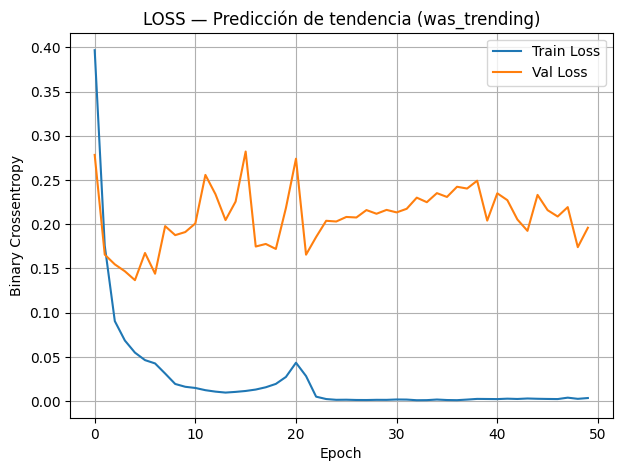

In [16]:
import matplotlib.pyplot as plt

train_loss = history.history.get("trend_output_loss", history.history["loss"])
val_loss   = history.history.get("val_trend_output_loss", history.history["val_loss"])

plt.figure(figsize=(7,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("LOSS — Predicción de tendencia (was_trending)")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.grid(True)
plt.legend()
plt.show()


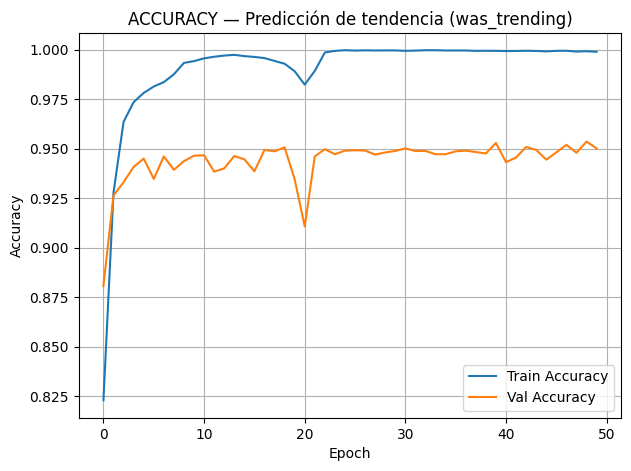

In [17]:
acc_key      = "trend_output_accuracy"
val_acc_key  = "val_trend_output_accuracy"

train_acc = history.history[acc_key]
val_acc   = history.history[val_acc_key]

plt.figure(figsize=(7,5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.title("ACCURACY — Predicción de tendencia (was_trending)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

embedding_val, trend_pred_val = model.predict(val_inputs, verbose=0)

trend_pred_val = trend_pred_val.flatten()


th = 0.5
y_pred_bin = (trend_pred_val >= th).astype(int)
cm = confusion_matrix(y_val, y_pred_bin)
print("Threshold:", th)
print("\nClassification report:\n", classification_report(y_val, y_pred_bin, digits=4))

Threshold: 0.5

Classification report:
               precision    recall  f1-score   support

           0     0.9701    0.9670    0.9685      4330
           1     0.8747    0.8855    0.8801      1127

    accuracy                         0.9502      5457
   macro avg     0.9224    0.9263    0.9243      5457
weighted avg     0.9504    0.9502    0.9503      5457



In [19]:
def inputs_for_all():
    inputs = {
        "numeric_input": X_num,
        "text_input": X_text
    }
    for col in cat_cols_ordered:
        inputs[f"{col}_input"] = X_cat[col]
    return inputs

all_inputs = inputs_for_all()
outs_all = model.predict(all_inputs, batch_size=1024)
embeddings_all = outs_all[0]
trend_preds_all = outs_all[1].ravel()

print("Embeddings shape:", embeddings_all.shape)
print("Trend preds shape:", trend_preds_all.shape)


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Embeddings shape: (27281, 64)
Trend preds shape: (27281,)


In [20]:
import pickle

os.makedirs("models", exist_ok=True)
EXPORT_PKL = "models/recommender.pkl"

export_obj = {
    "model_weights": model.get_weights(),
    "model_config": {
        "numeric_dim": X_num.shape[1],
        "text_dim": X_text.shape[1],
        "categorical_cols": cat_cols_ordered,
        "cat_cardinalities": {col: int(len(label_encoders[col].classes_)) for col in cat_cols_ordered},
        "embedding_dim": EMBEDDING_DIM
    },

    "scaler": scaler,
    "tfidf": tfidf,
    "svd": svd,
    "label_encoders": label_encoders,

    "embeddings": embeddings_all,
    "trend_preds": trend_preds_all,
    "ids": df["id"].tolist(),
    "names": df["name"].tolist(),
    "trend_labels": df["was_trending"].tolist(),
    "numeric_cols": numeric_cols,
    "categorical_cols": cat_cols_ordered,
    "text_col": text_col
}

with open(EXPORT_PKL, "wb") as f:
    pickle.dump(export_obj, f)

print("Exportado a", EXPORT_PKL, "con keys:", list(export_obj.keys()))

Exportado a models/recommender.pkl con keys: ['model_weights', 'model_config', 'scaler', 'tfidf', 'svd', 'label_encoders', 'embeddings', 'trend_preds', 'ids', 'names', 'trend_labels', 'numeric_cols', 'categorical_cols', 'text_col']


In [ ]:
import pickle
import numpy as np
from tensorflow.keras import layers, Model

# Cargar pkl
with open("models/recommender.pkl", "rb") as f:
    data = pickle.load(f)

model_config = data["model_config"]
model_weights = data["model_weights"]

scaler           = data["scaler"]
tfidf            = data["tfidf"]
svd              = data["svd"]
label_encoders   = data["label_encoders"]

ids              = data["ids"]
names            = data["names"]
embeddings_all   = data["embeddings"]
trend_labels     = data["trend_labels"]

OK — Modelo cargado.


In [ ]:
numeric_dim = model_config["numeric_dim"]
text_dim    = model_config["text_dim"]
cat_cols    = model_config["categorical_cols"]
cat_cards   = model_config["cat_cardinalities"]
embedding_dim = model_config["embedding_dim"]

# Inputs
numeric_in = layers.Input(shape=(numeric_dim,), name="numeric_input")
text_in    = layers.Input(shape=(text_dim,), name="text_input")

cat_inputs = {}
cat_embs = []
for col in cat_cols:
    inp = layers.Input(shape=(1,), dtype="int32", name=f"{col}_input")
    cat_inputs[col] = inp
    vocab = cat_cards[col] + 1
    emb_dim = min(50, max(4, int(1 + np.log2(max(2, cat_cards[col])) * 4)))
    emb = layers.Embedding(vocab, emb_dim)(inp)
    emb = layers.Flatten()(emb)
    cat_embs.append(emb)

# Construcción
concat = layers.Concatenate()([numeric_in, text_in] + cat_embs)
x = layers.Dense(256, activation="relu")(concat)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)

embedding_out = layers.Dense(embedding_dim, name="embedding")(x)
trend_out     = layers.Dense(1, activation="sigmoid", name="trend_output")(x)

model = Model(inputs=[numeric_in, text_in] + list(cat_inputs.values()),
              outputs=[embedding_out, trend_out])


print("Modelo reconstruido y pesos cargados.")

Modelo reconstruido y pesos cargados.


In [24]:
def build_input_single(row):
    num = scaler.transform([row[numeric_cols]])[0]
    text = svd.transform(tfidf.transform([row["lyrics"]]))[0]

    inputs = {
        "numeric_input": np.array([num]),
        "text_input": np.array([text])
    }
    for col in cat_cols:
        encoded = label_encoders[col].transform([str(row[col])])
        inputs[f"{col}_input"] = np.array(encoded).reshape(1,1)
    return inputs

row0 = df.iloc[3123]
inputs0 = build_input_single(row0)
_, pred_trending = model.predict(inputs0)

print("Canción:", row0["name"])
print("Probabilidad de ser trending:", f"{pred_trending[0][0]:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
Canción: Circles
Probabilidad de ser trending: 0.4900


In [32]:
from scipy.spatial.distance import cdist

def recommend(song_id, k=5):
    if song_id not in ids:
        raise ValueError("ID no encontrado.")
        
    idx = ids.index(song_id)
    vec = embeddings_all[idx].reshape(1,-1)

    dists = cdist(vec, embeddings_all, metric="cosine")[0]
    sims = 1 - dists

    sims[idx] = -999

    top = sims.argsort()[::-1][:k]
    results = [(ids[i], names[i], float(sims[i])) for i in top]
    return results

song_id = ids[3123]
print("Recomendaciones basadas en:", names[3123])
for r in recommend(song_id, k=10):
    print(r)


Recomendaciones basadas en: Circles
('7dt6x5M1jzdTEt8oCbisTK', 'Better Now', 0.9971476481690645)
('1YscJ7yVTlFxW3eF6pv5ba', 'Allergic', 0.9947840031480257)
('35r28RDot7nPE7y9K9H7l0', 'Feeling Whitney', 0.9929198566180908)
('05mDaV9Vb3wrzjF6OPZnhq', 'Saint-Tropez', 0.9925755666438906)
('32lItqlMi4LBhb4k0BaSaC', 'Candy Paint', 0.9911268534867668)
('2VdT56BGpdqNHUgOe1j5vc', 'Rich & Sad', 0.9882212220551394)
('0KAzP1Rbp0Vz5pw8i1KDDI', 'Internet', 0.984768976903739)
('5DLTuH4A5VZB2HKpqHQR6t', 'Patient', 0.9815911593891106)
('1ZemPoaj7LBj1RAQrb89EC', 'Blame It On Me', 0.981555095838243)
('4SYUUlkScpNR1QvPscXf8t', 'Too Young', 0.980128005419441)
